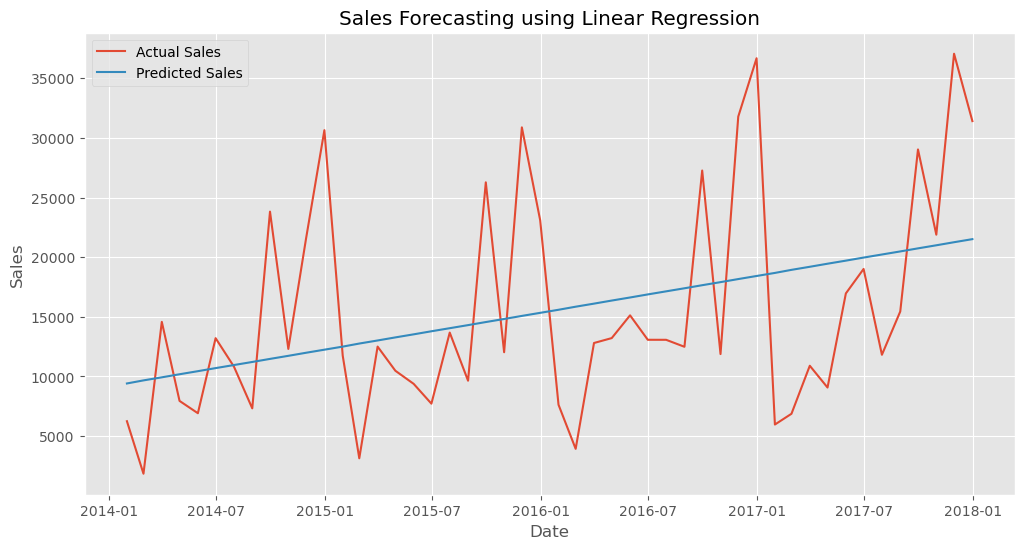

  Order Date      Sales  Predicted_Sales
0 2014-01-31   6242.525      9407.827135
1 2014-02-28   1839.658      9665.295302
2 2014-03-31  14573.956      9922.763470
3 2014-04-30   7944.837     10180.231637
4 2014-05-31   6912.787     10437.699804


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("stores_sales_forecasting.csv", encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.resample('ME',on='Order Date')['Sales'].sum().reset_index()

X = [[i] for i in range(len(monthly_sales))]
y = monthly_sales['Sales']
model = LinearRegression()
model.fit(X, y)
monthly_sales['Predicted_Sales'] = model.predict(X)
plt.style.use('ggplot')
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Order Date'],monthly_sales['Sales'],label='Actual Sales')
plt.plot(monthly_sales['Order Date'], monthly_sales['Predicted_Sales'],label='Predicted Sales')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting using Linear Regression")
plt.legend()
plt.show()
print(monthly_sales.head())